### Nama : Alvin Welva Al-Ghifari
### Kelas: VI B Pagi

In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

### 1. KONFIGURASI 

In [2]:
DATASET_PATH = 'TrashType_Image_Dataset' 
# MobileNetV2 optimal di ukuran 224x224
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
# Set Epochs tinggi tidak masalah, karena kita pakai Early Stopping
EPOCHS = 20 

print("Menyiapkan Data Generator...")

Menyiapkan Data Generator...


### 2. PREPROCESSING & DATA AUGMENTATION (Teknik Handling Overfitting 1)

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,       # Rotasi lebih besar
    width_shift_range=0.2,   # Geser gambar
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print(f"\nTotal Kelas Sampah: {NUM_CLASSES}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.

Total Kelas Sampah: 6


### 3. MEMBANGUN MODEL TRANSFER LEARNING (MobileNetV2)

In [4]:
print("\nMengunduh dan menyiapkan Base Model (MobileNetV2)...")
# Gunakan MobileNetV2 karena ringan dan sangat cepat untuk dilatih di laptop
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# KUNCI TRANSFER LEARNING: Freeze layer dasar agar tidak ikut dilatih ulang
base_model.trainable = False 

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    # Teknik Handling Overfitting 2: Dropout
    Dropout(0.5), 
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



Mengunduh dan menyiapkan Base Model (MobileNetV2)...


### 4. CALLBACKS (Teknik Handling Overfitting 3)

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

### 5. PELATIHAN MODEL (TRAINING)

In [6]:
print("\nMemulai proses Transfer Learning...")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop] # Memasukkan fungsi early stopping
)

# Simpan model
model.save('model_transfer_learning_sampah.h5')
print("\nModel berhasil disimpan: model_transfer_learning_sampah.h5")



Memulai proses Transfer Learning...
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 889ms/step - accuracy: 0.5484 - loss: 1.1778 - val_accuracy: 0.7237 - val_loss: 0.7578
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 870ms/step - accuracy: 0.7134 - loss: 0.7627 - val_accuracy: 0.7356 - val_loss: 0.7652
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 857ms/step - accuracy: 0.7416 - loss: 0.6852 - val_accuracy: 0.7515 - val_loss: 0.6891
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 879ms/step - accuracy: 0.7811 - loss: 0.6063 - val_accuracy: 0.7535 - val_loss: 0.6372
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 872ms/step - accuracy: 0.7890 - loss: 0.5696 - val_accuracy: 0.7495 - val_loss: 0.6912
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 885ms/step - accuracy: 0.8024 - loss: 0.5367 - val_accuracy: 0.7714 - val_loss: 0.6338
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 874ms/step - accuracy: 0.8142 - loss: 0.5263 - val_accuracy: 0.7893 - val_loss: 0.6185
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 887ms/step - accur


Model berhasil disimpan: model_transfer_learning_sampah.h5


### 6. PENGECEKAN OVERFITTING (VISUALISASI GRAFIK)


Membuat grafik performa untuk menganalisis overfitting...


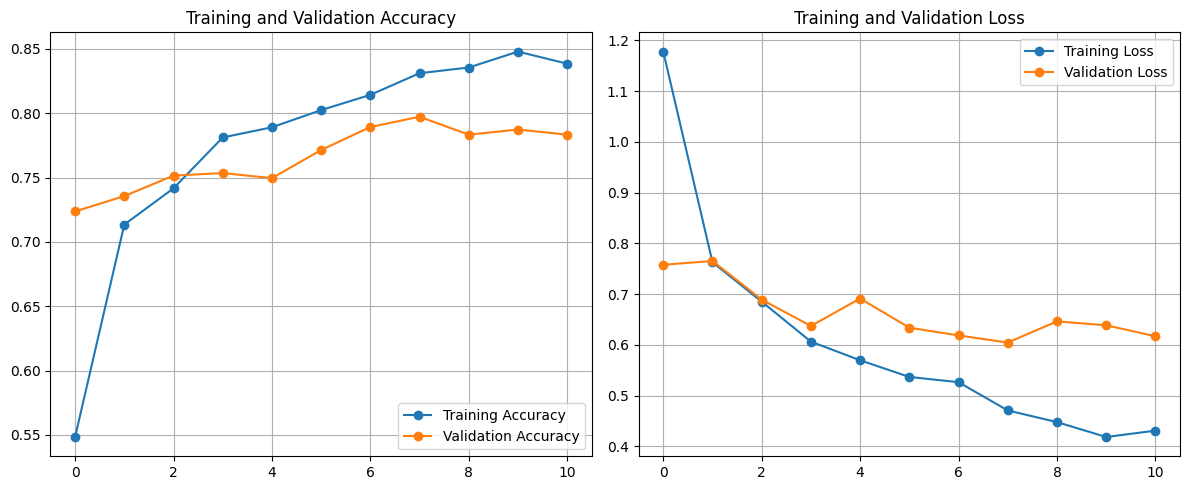

In [7]:
print("\nMembuat grafik performa untuk menganalisis overfitting...")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Grafik Loss (Paling penting untuk melihat overfitting)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show() # Jendela pop-up grafik akan muncul